In [2]:
from torch_geometric.datasets import TUDataset

dataset = TUDataset(root="/tmp/mutagenicity", name="Mutagenicity")

# let's inspect the data
print(f"The data has {len(dataset)} graph/s.")
print(f"The graph has {dataset[0].num_nodes} nodes.")
print(f"The graph has {dataset[0].num_edges} edges.")
print(f"The graph has an average node degree of {dataset[0].num_edges/dataset[0].num_nodes:.2f}.")
print(f"The graph is undirected {dataset[0].is_undirected()}.")
print(f"The graph has isolated nodes {dataset[0].has_isolated_nodes()}.")
print(f"The graph nodes have {dataset.num_features} features.")
print(f"The graph has {dataset.num_classes} classes.")
# print(f"The label rate in train data is: {dataset[0].train_mask.sum()/dataset[0].num_nodes:.3f}.")

The data has 4337 graph/s.
The graph has 16 nodes.
The graph has 32 edges.
The graph has an average node degree of 2.00.
The graph is undirected True.
The graph has isolated nodes False.
The graph nodes have 14 features.
The graph has 2 classes.


In [61]:
train_size = 0.8
val_size = 0.1

train_size = round(train_size*len(dataset))
val_size = round(val_size*len(dataset))

train_data = dataset[:train_size]
val_data = dataset[train_size:train_size+val_size]
test_data = dataset[train_size+val_size:]

from torch_geometric.loader import DataLoader
from torch_geometric.data import Data, Batch
from torch_geometric.nn import global_add_pool

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64)
test_data = Batch.from_data_list(test_data)

from torch_geometric.nn import GraphConv
import torch.nn as nn
import torch
from tqdm import tqdm

class GCN(nn.Module):
    def __init__(self, in_channel: int, hidden_channel: int, out_channel: int, p: float, num_classes: int):
        super().__init__()

        self.conv1 = GraphConv(in_channel, hidden_channel)
        self.conv2 = GraphConv(hidden_channel, hidden_channel)
        self.conv3 = GraphConv(hidden_channel, hidden_channel)
        self.conv4 = GraphConv(hidden_channel, out_channel)

        self.lin1 = nn.Linear(out_channel, out_channel)
        self.lin2 = nn.Linear(out_channel, num_classes)

        self.dropout = nn.Dropout(p)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, batch: torch.Tensor, edge_weight: torch.Tensor=None):
        x = self.conv1(x, edge_index, edge_weight).relu()
        x = self.dropout(x)
        
        x = self.conv2(x, edge_index, edge_weight).relu()
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_weight).relu()
        x = self.dropout(x)

        x = self.conv4(x, edge_index, edge_weight).relu()
        x = self.dropout(x)

        x = global_add_pool(x, batch)

        x = self.lin1(x).relu()
        x = self.dropout(x)

        return self.lin2(x)
    
def train(model: GCN, optimizer: torch.optim, data: Data, criterion: nn.CrossEntropyLoss):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.batch)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()
    return loss.detach().item()

def val(model:GCN, data:Data, criterion: nn.CrossEntropyLoss):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)

        return loss.item()
    
def acc(model: GCN, data: Data):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index, data.batch)
        y_pred = torch.argmax(out, dim=1)
        return (y_pred == data.y).float().mean().item()
    
model = GCN(in_channel=dataset.num_features, hidden_channel=64, out_channel=32, p=0.5, num_classes=2)
test_out = model(train_data[0].x, train_data[0].edge_index, train_data[0].batch)
test_batch = [*train_loader][0]
test_out_batch = model(test_batch.x, test_batch.edge_index, test_batch.batch)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
test_train_loss = train(model, optimizer, test_batch, criterion)
test_val_loss = val(model, test_batch, criterion)
test_train_acc = acc(model, test_batch)

def train_val(epochs: int, train_loader: DataLoader, val_loader: DataLoader, model: GCN, optimizer: torch.optim, criterion: nn.CrossEntropyLoss):
    train_loss = []
    val_loss = []

    train_acc = []
    val_acc = []

    for _ in tqdm(range(epochs)):
        t_loss = 0
        v_loss = 0

        t_acc = 0
        v_acc = 0
        for train_data in train_loader:
            t_loss += train(model, optimizer, train_data, criterion)
            t_acc += acc(model, train_data)
        t_loss /= len(train_loader)
        t_acc /= len(train_loader)

        for val_data in val_loader:
            v_loss += val(model, val_data, criterion)
            v_acc += acc(model, val_data)
        v_loss /= len(val_loader)
        v_acc /= len(val_loader)

        train_loss.append(t_loss)
        val_loss.append(v_loss)

        train_acc.append(t_acc)
        val_acc.append(v_acc)

    return {
        "model":model,
        "train_loss": train_loss,
        "val_loss": val_loss,

        "train_acc": train_acc,
        "val_acc": val_acc,
    }

result = train_val(100, train_loader, val_loader, model, optimizer, criterion)

100%|██████████| 100/100 [01:34<00:00,  1.05it/s]


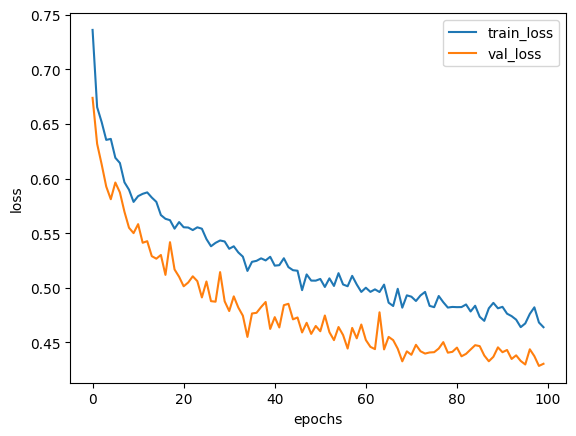

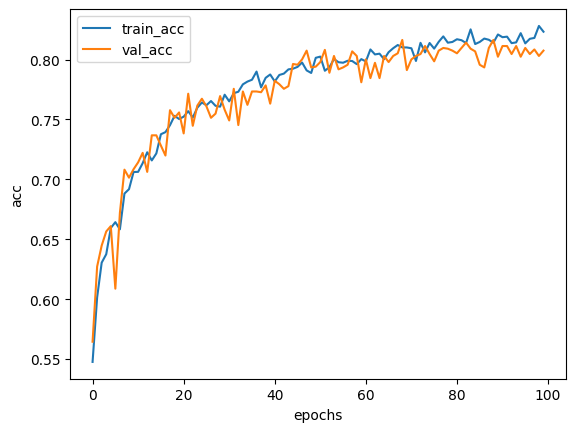

In [62]:
import matplotlib.pyplot as plt

plt.plot(result["train_loss"], label="train_loss")
plt.plot(result["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

plt.plot(result["train_acc"], label="train_acc")
plt.plot(result["val_acc"], label="val_acc")
plt.xlabel("epochs")
plt.ylabel("acc")
plt.legend()

plt.show()